In [ ]:
# This command will upgrade the transformers and datasets libraries to their latest versions
!pip install --upgrade transformers datasets

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

file_path = '/content/drive/MyDrive/colab_project_aiml/test.tsv'

try:
    df = pd.read_csv(file_path, sep='\t', names=['text', 'labels', 'id'])
    print("File loaded successfully from Google Drive!")
    print(df.head())
except FileNotFoundError:
    print(f"Error: Could not find file at '{file_path}'. Make sure the path is correct.")

File loaded successfully from Google Drive!
                                                text labels       id
0  I’m really sorry about your situation :( Altho...     25  eecwqtt
1    It's wonderful because it's awful. At not with.      0  ed5f85d
2  Kings fan here, good luck to you guys! Will be...     13  een27c3
3  I didn't know that, thank you for teaching me ...     15  eelgwd1
4  They got bored from haunting earth for thousan...     27  eem5uti


In [ ]:
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer

base_path = '/content/drive/MyDrive/colab_project_aiml/'
try:
    train_df = pd.read_csv(base_path + 'train.tsv', sep='\t', names=['text', 'labels', 'id'])
    dev_df = pd.read_csv(base_path + 'dev.tsv', sep='\t', names=['text', 'labels', 'id'])
    test_df = pd.read_csv(base_path + 'test.tsv', sep='\t', names=['text', 'labels', 'id'])
    print("Successfully loaded train.tsv, dev.tsv, and test.tsv.")
except FileNotFoundError as e:
    print(f"Error loading files: {e}")
    print("Please ensure all .tsv files are in the 'colab_project_aiml' folder in your Google Drive.")

# --- THIS IS THE KEY EDIT: We take a larger sample for training ---
train_df = train_df.head(10000)
print(f"Using a new, larger training set of: {len(train_df)} rows")
# ----------------------------------------------------------------

def preprocess_labels(df):
    """Converts the label string '2,15' into a list of integers [2, 15]."""
    # Ensure labels are strings before splitting
    df['labels_list'] = df['labels'].astype(str).str.split(',')
    # Convert the string numbers to integers
    df['labels_list'] = df['labels_list'].apply(lambda x: [int(i) for i in x])
    return df

train_df = preprocess_labels(train_df)
dev_df = preprocess_labels(dev_df)
test_df = preprocess_labels(test_df)


mlb = MultiLabelBinarizer()

# This will now correctly fit on the 10,000-entry sample
mlb.fit(train_df['labels_list'])

train_df['one_hot_labels'] = list(mlb.transform(train_df['labels_list']))
dev_df['one_hot_labels'] = list(mlb.transform(dev_df['labels_list']))
test_df['one_hot_labels'] = list(mlb.transform(test_df['labels_list']))

print("\nLabel pre-processing is complete.")
print("Here is a sample of the processed training data:")
print(train_df[['text', 'labels', 'one_hot_labels']].head())

Successfully loaded train.tsv, dev.tsv, and test.tsv.
Using a new, larger training set of: 10000 rows

Label pre-processing is complete.
Here is a sample of the processed training data:
                                                text labels  \
0  My favourite food is anything I didn't have to...     27   
1  Now if he does off himself, everyone will thin...     27   
2                     WHY THE FUCK IS BAYLESS ISOING      2   
3                        To make her feel threatened     14   
4                             Dirty Southern Wankers      3   

                                      one_hot_labels  
0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  
1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  
2  [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  
3  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...  
4  [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  


In [ ]:
# Install the transformers library
!pip install transformers[torch] datasets

# Import necessary libraries
import torch
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification, Trainer, TrainingArguments

In [ ]:
# Load the tokenizer
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

# Tokenize the text for all three datasets
train_encodings = tokenizer(train_df['text'].tolist(), truncation=True, padding=True)
dev_encodings = tokenizer(dev_df['text'].tolist(), truncation=True, padding=True)
test_encodings = tokenizer(test_df['text'].tolist(), truncation=True, padding=True)

print("Text tokenization complete.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

Text tokenization complete.


In [ ]:
# Create a PyTorch Dataset class
class EmotionDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        # Create a dictionary for the encodings and convert to PyTorch tensors
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        # Add the one-hot encoded labels as a tensor
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.float)
        return item

    def __len__(self):
        return len(self.labels)

# Create dataset objects for train and development sets
train_dataset = EmotionDataset(train_encodings, train_df['one_hot_labels'].tolist())
dev_dataset = EmotionDataset(dev_encodings, dev_df['one_hot_labels'].tolist())

print("PyTorch datasets created.")

PyTorch datasets created.


In [ ]:
# Load the pre-trained DistilBERT model
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=len(mlb.classes_), # The number of unique emotions
    problem_type="multi_label_classification" # Crucial for our task
)

# Define the training arguments
training_args = TrainingArguments(
    output_dir='./results',          # Directory to save the results
    num_train_epochs=3,              # Number of times to train on the whole dataset
    per_device_train_batch_size=16,  # Number of samples per batch
    per_device_eval_batch_size=16,   # Batch size for evaluation
    warmup_steps=500,                # Number of warmup steps for learning rate scheduler
    weight_decay=0.01,               # Strength of weight decay
    logging_dir='./logs',            # Directory for storing logs
    logging_steps=10,
    report_to="none",
)

# Create the Trainer instance
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=dev_dataset, # We use the dev set for evaluation
)

# --- Start Training ---
# This process might take some time depending on the Colab GPU allocated
print("Starting model fine-tuning...")
trainer.train()
print("Training complete!")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Starting model fine-tuning...


Step,Training Loss
10,0.691300
20,0.689800
30,0.683900
40,0.675000
50,0.659200
60,0.630600
70,0.583000
80,0.527900
90,0.476000
100,0.434200


Training complete!


In [ ]:
test_dataset = EmotionDataset(test_encodings, test_df['one_hot_labels'].tolist())

print("Successfully created the test_dataset.")

Successfully created the test_dataset.


In [ ]:

print("Evaluating model performance on the test set...")
eval_results = trainer.evaluate(test_dataset)

print("\nEvaluation Results:")
print(eval_results)

Evaluating model performance on the test set...



Evaluation Results:
{'eval_loss': 0.09256386011838913, 'eval_runtime': 9.4165, 'eval_samples_per_second': 576.326, 'eval_steps_per_second': 36.107, 'epoch': 3.0}


In [ ]:
# Define the path to your emotions.txt file
emotions_file_path = base_path + 'emotions.txt'

try:
    # Read the file line by line to create a list of emotion names
    with open(emotions_file_path, 'r') as f:
        emotion_names = [line.strip() for line in f.readlines()]

    print("Successfully created the 'emotion_names' list.")

    # Let's confirm what emotion #27 is
    label_to_check = 26
    print(f"Emotion label #{label_to_check} is: {emotion_names[label_to_check]}")

except FileNotFoundError:
    print(f"Please make sure 'emotions.txt' is in your Google Drive folder: {emotions_file_path}")

Successfully created the 'emotion_names' list.
Emotion label #26 is: surprise


In [ ]:
import numpy as np
import torch # Make sure torch is imported

# Get the raw predictions (logits) from the model
print("Making predictions on the test set...")
raw_predictions, _, _ = trainer.predict(test_dataset)

# Convert the raw numbers (logits) into probabilities (from 0 to 1)
sigmoid = torch.nn.Sigmoid()
probabilities = sigmoid(torch.from_numpy(raw_predictions))

# Decide which emotions are "active" based on a threshold (e.g., > 50% probability)
threshold = 0.25
predictions = (probabilities > threshold).int().numpy()

# Convert the numerical predictions back to human-readable emotion labels
# This uses the 'mlb' (MultiLabelBinarizer) you created earlier
predicted_labels = mlb.inverse_transform(predictions)

# Add the new predictions as a column in your test DataFrame
test_df['predicted_emotions'] = predicted_labels
test_df['prediction_probabilities'] = list(probabilities.numpy())
print("\nPredictions are complete. Here's a look at the model's output:")
# We show the original text, the true labels, and what our model predicted
print(test_df[['text', 'predicted_emotions']].head())

Making predictions on the test set...



Predictions are complete. Here's a look at the model's output:
                                                text predicted_emotions
0  I’m really sorry about your situation :( Altho...              (25,)
1    It's wonderful because it's awful. At not with.               (0,)
2  Kings fan here, good luck to you guys! Will be...            (0, 20)
3  I didn't know that, thank you for teaching me ...              (15,)
4  They got bored from haunting earth for thousan...              (27,)


In [ ]:

# This function will look up the names for a tuple of label numbers.
def map_labels_to_names(label_tuple):
    return tuple(emotion_names[label_id] for label_id in label_tuple)

# Apply the function to create a new column with the emotion names
test_df['predicted_emotion_names'] = test_df['predicted_emotions'].apply(map_labels_to_names)

print("Predictions with human-readable emotion names:")
# Display the text alongside the final, named emotions
print(test_df[['text', 'predicted_emotion_names']].head())

Predictions with human-readable emotion names:
                                                text predicted_emotion_names
0  I’m really sorry about your situation :( Altho...              (sadness,)
1    It's wonderful because it's awful. At not with.           (admiration,)
2  Kings fan here, good luck to you guys! Will be...  (admiration, optimism)
3  I didn't know that, thank you for teaching me ...            (gratitude,)
4  They got bored from haunting earth for thousan...              (neutral,)


In [ ]:
# === FINAL ANALYSIS CODE ===
# This is the code that works on your whole test set.

# 1. First, here is the final, corrected function for reference.
#    (You can re-run this or just ensure it's the version in your notebook's memory)
def prioritize_review(row, names_list):
    probabilities = row['prediction_probabilities']
    try:
        anger_index = names_list.index('anger')
        annoyance_index = names_list.index('annoyance')
        sadness_index = names_list.index('sadness')
    except (NameError, ValueError):
        return "N/A - Could not find required emotions in the loaded list"

    anger_prob = probabilities[anger_index]
    annoyance_prob = probabilities[annoyance_index]
    sadness_prob = probabilities[sadness_index]

    if anger_prob > 0.2 or annoyance_prob > 0.2:
        return "High Priority"
    elif sadness_prob > 0.2:
        return "Medium Priority"
    else:
        return "Low Priority"

# 2. Now, apply this function to your entire test_df DataFrame
print("Applying prioritization logic to the test set...")
# We use a lambda function here to correctly pass both the row and the emotion_names list
test_df['priority'] = test_df.apply(lambda row: prioritize_review(row, emotion_names), axis=1)
print("Prioritization complete.")


# 3. Finally, display the results
print("\n--- Prioritized Queue: High Priority Reviews ---")
high_priority_reviews = test_df[test_df['priority'] == 'High Priority']

if high_priority_reviews.empty:
    print("No high priority reviews found in the test set with the current rules.")
else:
    # Loop through and print each high-priority review
    for index, row in high_priority_reviews.iterrows():
        print(f"Review: {row['text']}")
        print(f"Detected Emotions: {row['predicted_emotion_names']}\n")

Applying prioritization logic to the test set...
Prioritization complete.

--- Prioritized Queue: High Priority Reviews ---
Review: Girlfriend weak as well, that jump was pathetic.
Detected Emotions: ('annoyance',)

Review: The thought of shooting anything at asylum seekers is appalling.
Detected Emotions: ()

Review: I know you're joking, but there are people here either stupid or desperate enough to believe and perpetuate such idiocy. 
Detected Emotions: ('annoyance',)

Review: You take that back right now! [NAME] does not deserve this.
Detected Emotions: ('disapproval', 'neutral')

Review: Borrowed time is stupid
Detected Emotions: ('anger', 'annoyance')

Review: Wouldn't wipe my arse with it.
Detected Emotions: ('anger', 'annoyance', 'neutral')

Review: Talk about an oldddd school shit coin.
Detected Emotions: ('anger', 'annoyance', 'neutral')

Review: TFW a sorceror cuts you root and stem and you hear someone's voice in flames as your junk burns.
Detected Emotions: ('anger', 'anno

--- Generating Final Visualizations ---


/tmp/ipython-input-3213296762.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Emotion', data=emotion_counts_df, palette='viridis')


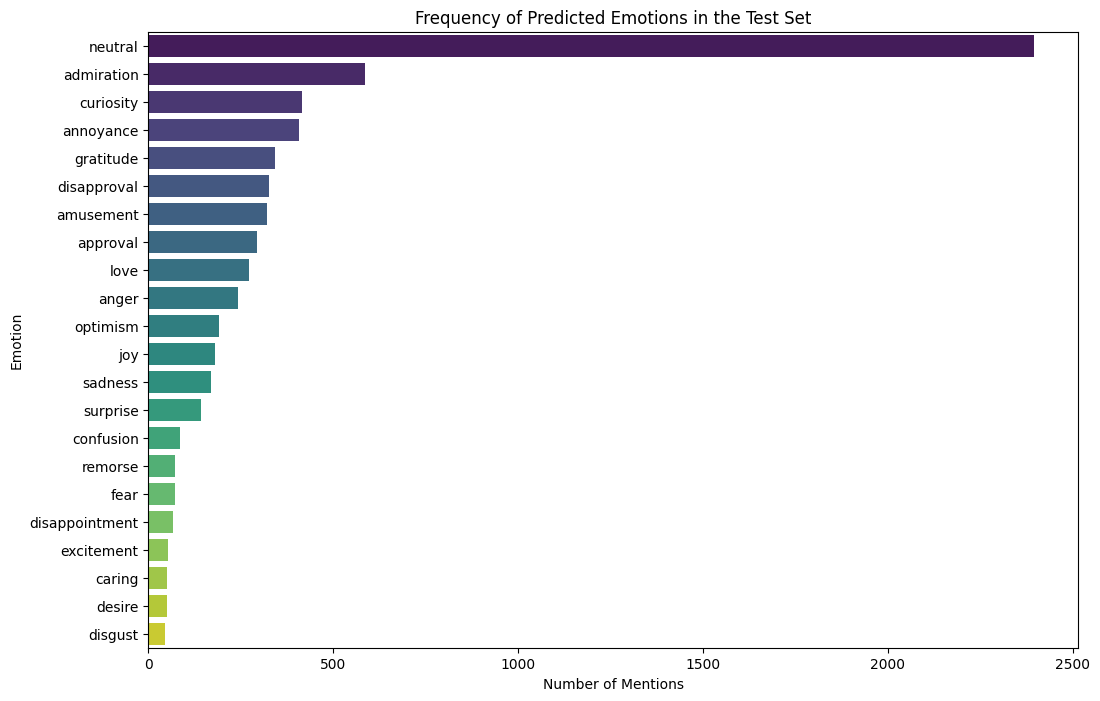

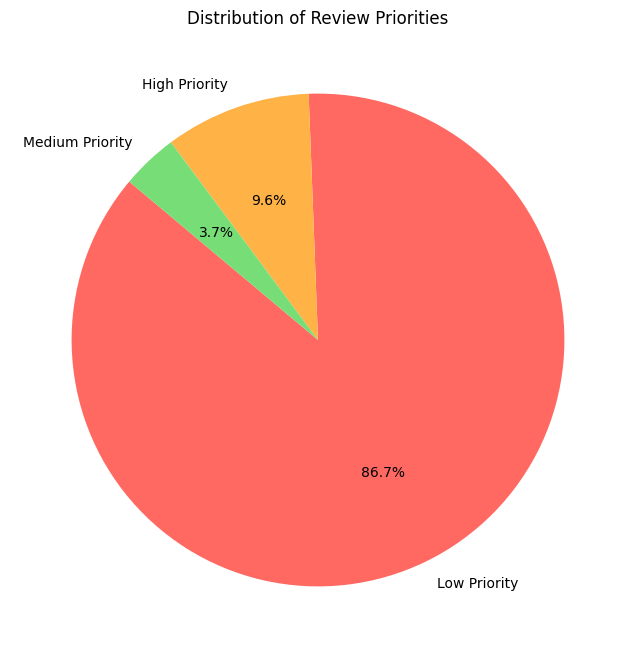


--- Project Complete ---


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import pandas as pd

print("--- Generating Final Visualizations ---")

# --- Visualization 1: Emotion Frequency Bar Chart ---
# Flatten the list of all predicted emotions into a single list
all_predicted_emotions = [emotion for emotions_list in test_df['predicted_emotion_names'] for emotion in emotions_list]

# Count the occurrences of each emotion
emotion_counts = Counter(all_predicted_emotions)

# Create a DataFrame for plotting
emotion_counts_df = pd.DataFrame(emotion_counts.items(), columns=['Emotion', 'Count']).sort_values(by='Count', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Count', y='Emotion', data=emotion_counts_df, palette='viridis')
plt.title('Frequency of Predicted Emotions in the Test Set')
plt.xlabel('Number of Mentions')
plt.ylabel('Emotion')
plt.show()


# --- Visualization 2: Priority Distribution Pie Chart ---
priority_counts = test_df['priority'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(priority_counts, labels=priority_counts.index, autopct='%1.1f%%', startangle=140, colors=['#ff6961', '#ffb347', '#77dd77', '#aec6cf'])
plt.title('Distribution of Review Priorities')
plt.show()

print("\n--- Project Complete ---")

In [ ]:
def generate_response_template(row):
    """
    Generates a suggested response based on the review's priority and emotions.
    """
    priority = row['priority']
    emotions = row['predicted_emotion_names']

    # --- High Priority (Anger, Annoyance) ---
    if priority == 'High Priority':
        return "We are very sorry to hear about your negative experience. Your feedback is important, and we want to make things right. Please contact our support team at support@example.com with your user details so we can investigate this for you immediately."

    # --- Medium Priority (Sadness, Disappointment) ---
    elif priority == 'Medium Priority':
        return "We're sorry that your experience didn't meet your expectations. We appreciate you taking the time to share your feedback and our team will look into the issues you've mentioned."

    # --- Low Priority & Positive ---
    elif 'gratitude' in emotions or 'joy' in emotions or 'love' in emotions or 'admiration' in emotions:
        return "Thank you so much for your positive feedback! We're thrilled to hear you had a great experience and appreciate you taking the time to share."

    # --- Default for Neutral/Other Low Priority ---
    else:
        return "Thank you for your feedback. We appreciate you sharing your thoughts with us."

# Apply this function to your test_df to create a new 'suggested_response' column
test_df['suggested_response'] = test_df.apply(generate_response_template, axis=1)

print("Successfully generated response templates.")

Successfully generated response templates.


In [ ]:
# Create a new DataFrame containing only the reviews that require action
action_queue_df = test_df[test_df['priority'] != 'Low Priority'].copy()

print("--- DAILY ACTION QUEUE ---")
if action_queue_df.empty:
    print("No high or medium priority reviews found that require a response.")
else:
    # Loop through the actionable reviews and display them clearly
    for index, row in action_queue_df.iterrows():
        print(f"REVIEW: \"{row['text']}\"")
        print(f"DETECTED EMOTIONS: {row['predicted_emotion_names']}")
        print(f"PRIORITY: {row['priority']}")
        print(f"SUGGESTED RESPONSE: \"{row['suggested_response']}\"")
        print("-" * 20) # Separator

--- DAILY ACTION QUEUE ---
REVIEW: "I’m really sorry about your situation :( Although I love the names Sapphira, Cirilla, and Scarlett!"
DETECTED EMOTIONS: ('sadness',)
PRIORITY: Medium Priority
SUGGESTED RESPONSE: "We're sorry that your experience didn't meet your expectations. We appreciate you taking the time to share your feedback and our team will look into the issues you've mentioned."
--------------------
REVIEW: "I’m sorry to hear that friend :(. It’s for the best most likely if she didn’t accept you for who you are"
DETECTED EMOTIONS: ('remorse', 'sadness')
PRIORITY: Medium Priority
SUGGESTED RESPONSE: "We're sorry that your experience didn't meet your expectations. We appreciate you taking the time to share your feedback and our team will look into the issues you've mentioned."
--------------------
REVIEW: "Girlfriend weak as well, that jump was pathetic."
DETECTED EMOTIONS: ('annoyance',)
PRIORITY: High Priority
SUGGESTED RESPONSE: "We are very sorry to hear about your negat

In [ ]:
import joblib

# 1. Save the fine-tuned model and tokenizer
trainer.save_model('./final_model')
tokenizer.save_pretrained('./final_model')

# 2. Save the MultiLabelBinarizer
# Make sure 'mlb' is the binarizer you fitted on the 10,000-entry dataset
joblib.dump(mlb, 'mlb.pkl')

# Now, use the file browser on the left to download:
# 1. The entire 'final_model' folder (you may need to zip it first).
# 2. The 'mlb.pkl' file.
# 3. The 'emotions.txt' file from your Google Drive.

['mlb.pkl']